# Homework 10b — Time Series Classification
This notebook builds a leakage-aware baseline that predicts whether the next business-day return will be positive. It uses the supplied synthetic financial series so the workflow is fully reproducible.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## 1. Data
The supplied generator creates 500 business-day observations with a change in drift and volatility plus five random jumps. The fixed seed makes the experiment reproducible.

In [3]:
# The assignment permits either project data or the supplied synthetic data.
# This submission uses the synthetic series below for a self-contained baseline.

### Synthetic financial time series

In [4]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


## 2. Leakage-aware feature engineering
Every predictor is shifted by one day, so the row dated $t$ contains information available only through $t-1$. The target is the sign of the return at $t+1$.

In [5]:
# Lag and rolling features use past observations only.
df['lag_1'] = df['ret'].shift(1)
df['lag_2'] = df['ret'].shift(2)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_std_20'] = df['ret'].rolling(20).std().shift(1)
df['momentum_5'] = df['price'].pct_change(5).shift(1)
df['zscore_20'] = ((df['ret'] - df['ret'].rolling(20).mean()) /
                   df['ret'].rolling(20).std()).shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df_feat = df.dropna().copy()
df_feat[['ret', 'lag_1', 'lag_2', 'roll_mean_5', 'roll_std_20',
         'momentum_5', 'zscore_20', 'y_next_ret', 'y_up']].head()

,ret,lag_1,lag_2,roll_mean_5,roll_std_20,momentum_5,zscore_20,y_next_ret,y_up
2021-01-29,0.016949,-0.014854,0.003049,-0.003707,0.007370,-0.018593,-1.801940,0.001845,1
2021-02-01,0.001845,0.016949,-0.014854,0.002509,0.008455,0.012347,2.090596,-0.003565,0
2021-02-02,-0.003565,0.001845,0.016949,0.001706,0.008429,0.008303,0.268365,0.020804,1
2021-02-03,0.020804,-0.003565,0.001845,0.000685,0.008453,0.003163,-0.347615,-0.000154,0
2021-02-04,-0.000154,0.020804,-0.003565,0.004236,0.009675,0.020920,2.130277,-0.014106,0


## 3. Time-aware split
The earliest 80% of observations form the training set and the most recent 20% form the test set. No shuffling is used because it would let future market regimes influence training.

In [6]:
# Time-aware split
cut = int(len(df_feat) * 0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features = ['lag_1', 'lag_2', 'roll_mean_5', 'roll_std_20', 'momentum_5', 'zscore_20']
X_tr, X_te = train[features], test[features]
y_tr, y_te = train['y_up'], test['y_up']
print(f'Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)')
print(f'Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)')
print(f'Train positive rate: {y_tr.mean():.3f}; test positive rate: {y_te.mean():.3f}')

Train: 2021-01-29 to 2022-07-19 (383 rows)
Test:  2022-07-20 to 2022-11-30 (96 rows)
Train positive rate: 0.462; test positive rate: 0.448


## 4. Pipeline and classification model
`StandardScaler` is fitted only on the training period inside the pipeline. Logistic regression then estimates the probability of a positive next-day return.

In [7]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(solver='liblinear', max_iter=1000, random_state=7))
])
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)
pred_prob = clf.predict_proba(X_te)[:, 1]

Accuracy:  0.542
Precision: 0.478
Recall:    0.256
F1:        0.333
Majority-class accuracy baseline: 0.552

              precision    recall  f1-score   support

        Down       0.56      0.77      0.65        53
          Up       0.48      0.26      0.33        43

    accuracy                           0.54        96
   macro avg       0.52      0.51      0.49        96
weighted avg       0.52      0.54      0.51        96



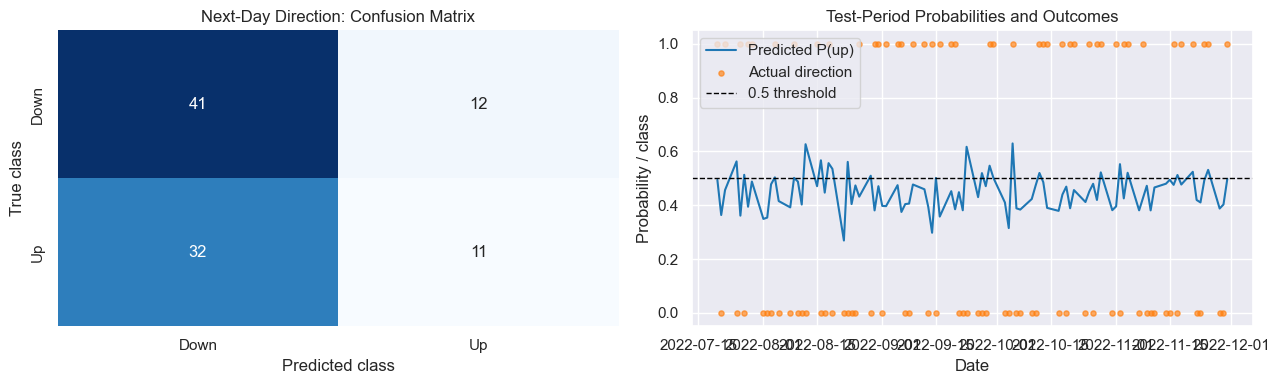

In [8]:
accuracy = accuracy_score(y_te, pred)
precision = precision_score(y_te, pred, zero_division=0)
recall = recall_score(y_te, pred, zero_division=0)
f1 = f1_score(y_te, pred, zero_division=0)
majority_accuracy = y_te.value_counts(normalize=True).max()
print(f'Accuracy:  {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1:        {f1:.3f}')
print(f'Majority-class accuracy baseline: {majority_accuracy:.3f}\n')
print(classification_report(y_te, pred, target_names=['Down', 'Up'], zero_division=0))

cm = confusion_matrix(y_te, pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[0].set_title('Next-Day Direction: Confusion Matrix')
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('True class')
axes[1].plot(test.index, pred_prob, label='Predicted P(up)', color='tab:blue')
axes[1].scatter(test.index, y_te, label='Actual direction', color='tab:orange', s=14, alpha=0.65)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='0.5 threshold')
axes[1].set_title('Test-Period Probabilities and Outcomes')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Probability / class')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()

## 5. Interpretation

**What worked.** The notebook implements six predictors from lag, rolling-statistic, momentum, and z-score families. Because every predictor is shifted, none uses the current or next-day return. The chronological holdout and pipeline also prevent leakage from random splitting or full-sample scaling. The confusion matrix and accuracy, precision, recall, and F1 score show performance across both classes, while the majority-class baseline provides necessary context.

**What fails or remains weak.** Daily returns in this synthetic series are largely random, so past-return features may contain little stable information about tomorrow's sign. Accuracy close to the majority baseline would not demonstrate an economically useful signal. Precision and recall can also move substantially with the 0.5 cutoff, and none of these metrics includes trading costs or the size of gains and losses.

**Where assumptions can break.** Logistic regression assumes a stable linear relationship between scaled features and log-odds. The generator intentionally changes drift and volatility halfway through and includes jumps, so the data are nonstationary and observations may not be identically distributed. Overlapping rolling windows also create dependence among feature rows. A single 80/20 split measures only one market regime and may be sensitive to the cutoff.

**Next steps.** I would use expanding-window or rolling `TimeSeriesSplit`, compare several probability thresholds, and report balanced accuracy or ROC-AUC in addition to the required metrics. I would also test economically motivated predictors, probability calibration, and a transaction-cost-aware backtest. More flexible models should be accepted only if they improve multiple out-of-sample windows without leakage.

## 6. Conclusion
This is a reproducible, leakage-aware classification baseline rather than evidence of a tradable strategy. Its value is to establish an honest benchmark and a validation pattern that can later be adapted to project data.